In [1]:
# PHASE 0 — Clean Minimal Install

%pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
%pip install transformers roboflow pycocotools
%pip install opencv-python pillow matplotlib numpy tqdm

print("Phase 0 Complete — Minimal Dependencies Installed")

Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/113.7 MB ? eta -:--:--
   - -------------------------------------- 3.4/113.7 MB 25.2 MB/s eta 0:00:05
   -- ------------------------------------- 7.9/113.7 MB 19.5 MB/s eta 0:00:06
   ---- ----------------------------------- 12.6/113.7 MB 20.2 MB/s eta 0:00:05
   ------ --------------------------------- 17.6/113.7 MB 21.3 MB/s eta 0:00:05
   -------- ------------------------------- 22.8/113.7 MB 21.9 MB/s eta 0:00:05
   --------- ------------------------------ 27.5/113.7 MB 21.8 MB/s eta 0:00:04
   ----------- ---------------------------- 32.5/113.7 MB 22.0 MB/s eta 0:00:04
   ------------- -------------------------- 37.2/113.7 MB 21.9 MB/s eta 0:00:04
   -------------- ------------------------- 


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
  Using cached regex-2026.1.15-cp312-cp312-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached certifi-2026.1.4-py3-none-any.whl.metadata (2.5 kB)
  Using cached python_dotenv-1.2.1-py3-none-any.whl.metadata (25 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached hf_xet-1.2.0-cp37-abi3-win_amd64.whl.metadata (5.0 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached charse


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   -- ------------------------------------- 2.1/40.2 MB 11.7 MB/s eta 0:00:04
   ----- ---------------------------------- 5.2/40.2 MB 13.8 MB/s eta 0:00:03
   -------- ------------------------------- 8.7/40.2 MB 13.8 MB/s eta 0:00:03
   ------------- -------------------------- 13.1/40.2 MB 15.8 MB/s eta 0:00:02
   ----------------- ---------------------- 17.6/40.2 MB 17.0 MB/s eta 0:00:02
   --------------------- ------------------ 22.0/40.2 MB 17.6 MB/s eta 0:00:02
   ------------------------- -------------- 26.0/40.2 MB 18.1 MB/s eta 0:00:01
   ----------------------------- ---------- 29.9/40.2 MB 18.2 MB/s eta 0:00:01
   ---------------------------------- ----- 34.3/40.2 MB 18.2 MB/s eta 0:00:01
   -------------------------------------- - 38.5/40.2 MB 18.4 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 17.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


loading Roboflow workspace...
loading Roboflow project...
Dataset cached at: c:\Users\GCV\dev\work\steel-defect-detection\notebook\NEU-Surface-Defect-Dataset-1
COCO Annotation Found: c:\Users\GCV\dev\work\steel-defect-detection\notebook\NEU-Surface-Defect-Dataset-1\valid\_annotations.coco.json
Using image: c:\Users\GCV\dev\work\steel-defect-detection\notebook\NEU-Surface-Defect-Dataset-1\train\pitted_surface_223_jpg.rf.494dee5db5e7af8b912c44a2957e8b0a.jpg


Loading weights: 100%|██████████| 1206/1206 [00:01<00:00, 729.43it/s, Materializing param=model.text_projection.weight]                                                                           


Grounding DINO Loaded
Detections after threshold: 0


The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.


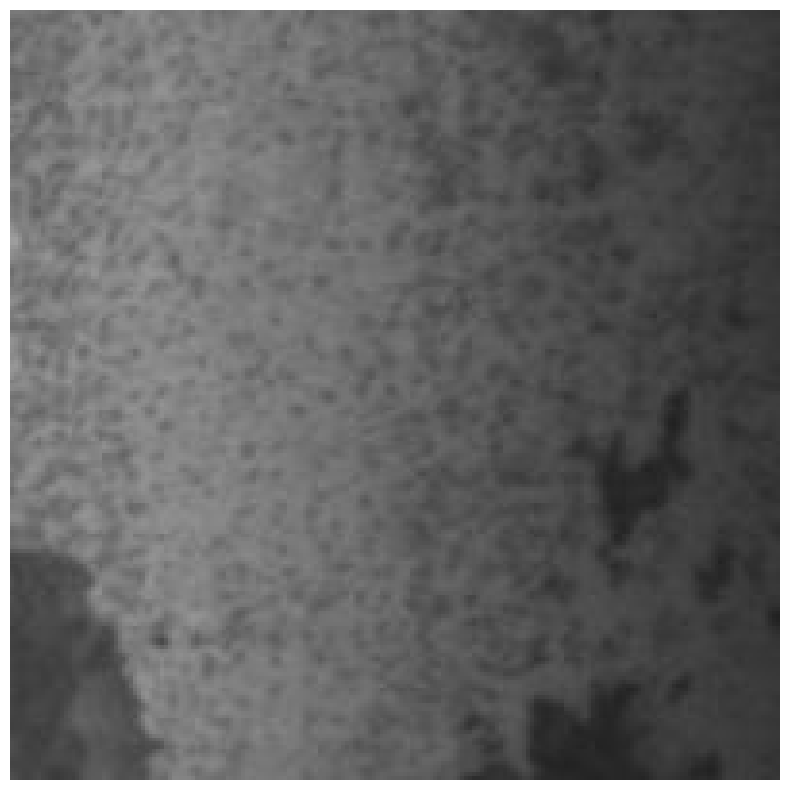

PHASE 1 COMPLETE — Detection Working


In [3]:
# =========================================
# PHASE 1 — Roboflow + Grounding DINO Detection (UPDATED)
# =========================================

# Install Roboflow if missing (safe to keep)
!pip install -q roboflow

import os
import random
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from roboflow import Roboflow
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

# -----------------------------
# 1. Download Dataset (Roboflow auto-cache)
# -----------------------------
rf = Roboflow(api_key="mYBoLp62ZUUfrZdCQn6q")
project = rf.workspace("antino-h3lcd").project("neu-surface-defect-dataset-ikvj9")
version = project.version(1)
dataset = version.download("coco")

dataset_path = dataset.location
print("Dataset cached at:", dataset_path)

# -----------------------------
# 2. Check for COCO annotations
# -----------------------------
ann_path = None
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if f.endswith(".json"):
            ann_path = os.path.join(root, f)

if ann_path:
    print("COCO Annotation Found:", ann_path)
else:
    print("No Annotation File Found — Evaluation will be weak")

# -----------------------------
# 3. Load ONE random image
# -----------------------------
image_files = []
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(root, f))

assert len(image_files) > 0, "No images found!"

img_path = random.choice(image_files)
print("Using image:", img_path)

image_pil = Image.open(img_path).convert("RGB")

# -----------------------------
# 4. Load Grounding DINO (Pretrained)
# -----------------------------
model_id = "IDEA-Research/grounding-dino-base"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id)

print("Grounding DINO Loaded")

# -----------------------------
# 5. NEU Steel Defect Prompt
# -----------------------------
defect_prompt = """
crazing defect,
inclusion defect,
surface patches,
pitted surface defect,
rolled in scale defect,
scratches defect,
steel surface defect
"""

inputs = processor(images=image_pil, text=defect_prompt, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

# -----------------------------
# 6. Updated Post-process (New Transformers API)
# -----------------------------
results = processor.post_process_grounded_object_detection(
    outputs=outputs,
    input_ids=inputs.input_ids,
    target_sizes=[image_pil.size[::-1]]
)

# Manual threshold filtering
boxes = []
scores = []
labels = []

for score, label, box in zip(
    results[0]["scores"],
    results[0]["labels"],
    results[0]["boxes"]
):
    if score >= 0.30:   # confidence threshold
        boxes.append(box)
        scores.append(score)
        labels.append(label)

print(f"Detections after threshold: {len(boxes)}")

# -----------------------------
# 7. Draw Bounding Boxes
# -----------------------------
img = np.array(image_pil)
img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

for box, score, label in zip(boxes, scores, labels):
    x1, y1, x2, y2 = map(int, box.tolist())
    cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
    cv2.putText(img, f"{label}:{score:.2f}", (x1, y1-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.show()

print("PHASE 1 COMPLETE — Detection Working")


Raw detections: 6
Detections after NMS: 1


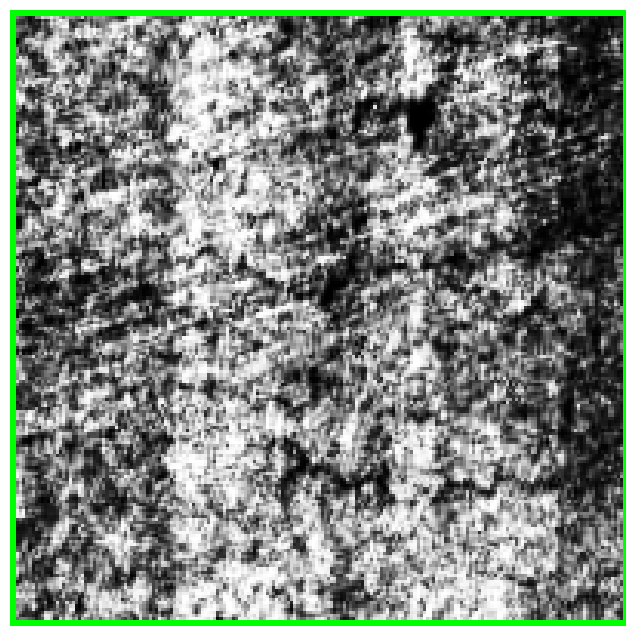

PHASE 2 COMPLETE — Improved Detection with NMS


In [6]:
# =========================================
# PHASE 2 — Improved Multi-Defect Detection + NMS
# (Reuses Phase 1: image_pil, processor, model)
# =========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.ops as ops
from PIL import Image

# -----------------------------
# 1. Contrast Enhancement (important for NEU)
# -----------------------------
img_np = np.array(image_pil)
lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(lab)
l = cv2.equalizeHist(l)
lab = cv2.merge((l, a, b))
enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
image_enhanced = Image.fromarray(enhanced)

# -----------------------------
# 2. Stronger Class Prompts
# -----------------------------
classes = {
    "crazing": "tiny cracks crazing defect on metal steel surface",
    "inclusion": "small inclusion impurity defect on steel surface",
    "patches": "irregular surface patches defect on steel",
    "pitted_surface": "small holes pitted surface defect on metal",
    "rolled-in_scale": "rolled in scale defect dark marks on steel",
    "scratches": "thin scratches defect on steel surface"
}

all_boxes, all_scores, all_labels = [], [], []

# -----------------------------
# 3. Detection per class
# -----------------------------
for class_name, prompt in classes.items():

    inputs = processor(images=image_enhanced, text=prompt, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    results = processor.post_process_grounded_object_detection(
        outputs=outputs,
        input_ids=inputs.input_ids,
        target_sizes=[image_enhanced.size[::-1]]
    )

    for score, box in zip(results[0]["scores"], results[0]["boxes"]):
        if score >= 0.18:   # lower threshold for NEU dataset
            all_boxes.append(box)
            all_scores.append(score)
            all_labels.append(class_name)

print(f"Raw detections: {len(all_boxes)}")

# -----------------------------
# 4. Apply Non-Max Suppression (NMS)
# -----------------------------
if len(all_boxes) > 0:
    boxes_tensor = torch.stack(all_boxes)
    scores_tensor = torch.tensor(all_scores)

    keep = ops.nms(boxes_tensor, scores_tensor, iou_threshold=0.4)

    nms_boxes = [all_boxes[i] for i in keep]
    nms_scores = [all_scores[i] for i in keep]
    nms_labels = [all_labels[i] for i in keep]
else:
    nms_boxes, nms_scores, nms_labels = [], [], []

print(f"Detections after NMS: {len(nms_boxes)}")

# -----------------------------
# 5. Draw Bounding Boxes
# -----------------------------
img = np.array(image_enhanced)
img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

for box, score, label in zip(nms_boxes, nms_scores, nms_labels):
    x1, y1, x2, y2 = map(int, box.tolist())
    cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
    cv2.putText(img, f"{label}:{score:.2f}", (x1, y1-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

print("PHASE 2 COMPLETE — Improved Detection with NMS")
